In [7]:
# using the powerplant dataset:

In [8]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv("/Powerplant dataset.csv")

In [10]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


- AT - Temperature value
- V - Vaccum
- AP - Pressure
- RH - Humidity

- PR - Produced energy (output)

In [11]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [12]:
X = df.drop(columns=["PE"], axis=1)
y= df["PE"]

# Steps that we will follow:
1. Load the data
2. Data tranformation to tensor
3. Tensor dataset & Dataloader
4. Define ANN Model
5. Train the model

In [13]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#appplying the standard scaler:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [15]:
# Conversion of data set to Tensors

# tensors are core data structres of pytorch

import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled , dtype=torch.float32)

 # Using.view(-1 , 1) to convert the 1D shape, here -1 means to automatically detect the rows, 1 represents the number of columns:
y_train_tensor = torch.tensor(y_train.values , dtype=torch.float32).view(-1 , 1)

X_test_tensor = torch.tensor(X_test_scaled , dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype=torch.float32).view(-1 , 1)

# Architecture:

- inputs :
 - x1- temp
 - x2-vaccum
 - x3- pressure
 - x4- humidity


- we will have 2 hidden layers , 6 neurons in each layer

In [16]:
# DATA Loader creates the batches for us
# Data Loader also define how the data will be laded for the training
# Tensor data set class is a class that helps the dataloader to access the data, becasue the dataloader is not cabable to access directly


# implementation"

In [2]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

NameError: name 'X_train_tensor' is not defined

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Building ANN Model:

In [19]:
# ANN model is trained in the form of class , which will be built on a base class nn.module

In [20]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
             #1st hidden:
             # nn.Linear (in_features, out_features) - syntax
             nn.Linear(X_train.shape[1], 6),
             nn.ReLU(),

         # 2nd hidden layer
             nn.Linear (6, 6),
             nn.ReLU(),

         #output layer
             nn.Linear(6,1),
        )

    def forward(self, x):
            return self.model(x)

       #pytorch will handel backward propagation automatically (autograd handels it)

In [21]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

### Training the model:

In [22]:
# we are going to have 100 epochs

train_losses = []
val_losses = []

best_val_loss = float("inf")

epoches = 100

for epoch in range(epoches):
    model.train()              # model adjusts the weights in the train mode
    running_loss = 0.0 #total training loss for 2 epoch

    for xb, yb in train_loader:
        # train loader will give us batch, xb = features of 1 batch and yb= labels of one batch

        optimizer.zero_grad()
        outputs = model(xb)   # predicted outputs for this batch
        loss = crietrion(outputs, yb)
        loss.backward()    #back propagation, computes the gradients
        optimizer.step() # params update

        running_loss += loss.item()  # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation:
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss


    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)


    print(f"epoch ${epoch+1}/{epoches} ==> train loss = ${epoch_train_loss} & val loss =${epoch_val_loss}")

    ## SAving the best model
    if epoch_val_loss <  best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch $1/100 ==> train loss = $205688.48548177083 & val loss =$203519.265625
epoch $2/100 ==> train loss = $194481.92317708334 & val loss =$177704.109375
epoch $3/100 ==> train loss = $147470.65045572916 & val loss =$112445.953125
epoch $4/100 ==> train loss = $78450.71845703125 & val loss =$49282.50390625
epoch $5/100 ==> train loss = $33994.48090820313 & val loss =$24026.6953125
epoch $6/100 ==> train loss = $20910.132670084637 & val loss =$17956.0703125
epoch $7/100 ==> train loss = $16659.582071940105 & val loss =$14474.0205078125
epoch $8/100 ==> train loss = $13267.588358561197 & val loss =$11238.728515625
epoch $9/100 ==> train loss = $10058.162800089518 & val loss =$8211.9326171875
epoch $10/100 ==> train loss = $7142.309371948242 & val loss =$5594.45556640625
epoch $11/100 ==> train loss = $4716.708652750651 & val loss =$3532.840087890625
epoch $12/100 ==> train loss = $2892.7801010131834 & val loss =$2091.8134765625
epoch $13/100 ==> train loss = $1686.938721593221 & val loss

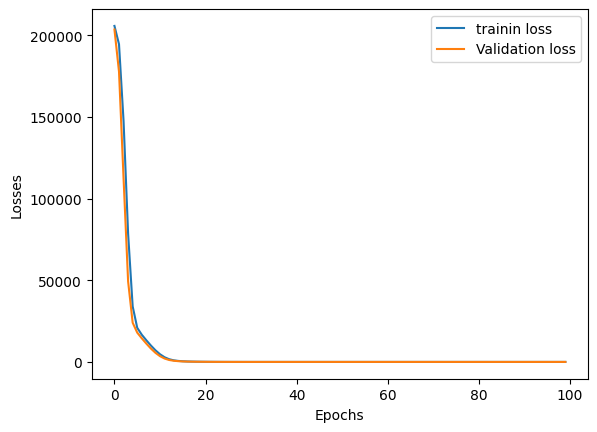

In [23]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss" : val_losses
})

plt.plot(loss_df["train_loss"], label = "trainin loss")
plt.plot(loss_df["val_loss"], label = "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [24]:
# loading the best model:
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

### Evaluating the model:

#### we need to compute 3 things:
1. Training MSE
2. Testing MSE
3. R2 score

In [25]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)


    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE : ", train_mse_loss.item())
print("Testing MSE : ", test_mse_loss.item())

Training MSE :  20.09392547607422
Testing MSE :  18.305498123168945


In [26]:
from sklearn.metrics import r2_score

print("r2 score = ", r2_score(y_test, test_preds))

r2 score =  0.9360270106005213


In [27]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"] )
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"] )

pd.concat([ predicted_df, actual_df])

,Predicted Values,Actual Values
0,434.972778,NaN
1,436.285522,NaN
2,460.995239,NaN
3,476.135132,NaN
4,434.549561,NaN
...,...,...
1909,NaN,456.70
1910,NaN,438.04
1911,NaN,467.80
1912,NaN,437.14
